In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

os.makedirs("reports/charts", exist_ok=True)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load cleaned datasets

nav = pd.read_csv("data/processed/cleaned_nav_history.csv")
transactions = pd.read_csv("data/processed/cleaned_investor_transactions.csv")
scheme = pd.read_csv("data/processed/cleaned_scheme_performance.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

# Convert date columns
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("=" * 60)
print("DATASETS LOADED")
print("=" * 60)

print("NAV History       :", nav.shape)
print("Transactions      :", transactions.shape)
print("Scheme Performance:", scheme.shape)
print("Benchmark         :", benchmark.shape)

print("\nBenchmark indices:")
print(benchmark["index_name"].unique())

DATASETS LOADED
NAV History       : (46000, 3)
Transactions      : (32778, 13)
Scheme Performance: (40, 19)
Benchmark         : (8050, 3)

Benchmark indices:
<ArrowStringArray>
['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']
Length: 7, dtype: str


In [3]:
# TASK 1: DAILY RETURNS

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"]).copy()

# Calculate daily return for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print("=" * 60)
print("DAILY RETURNS CALCULATED")
print("=" * 60)

print("\nFirst 10 rows:")
print(
    nav[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

print("\nDaily Return Statistics:")
print(
    nav["daily_return"]
    .dropna()
    .describe()
)

DAILY RETURNS CALCULATED

First 10 rows:
   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073

Daily Return Statistics:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


DAILY RETURN VALIDATION
Total daily return observations: 45960
Minimum daily return: -0.058102013949189124
Maximum daily return: 0.06471309359097144
Mean daily return: 0.0006310517590547711
Median daily return: 0.0003402087746056104
Standard deviation: 0.010290414788248919


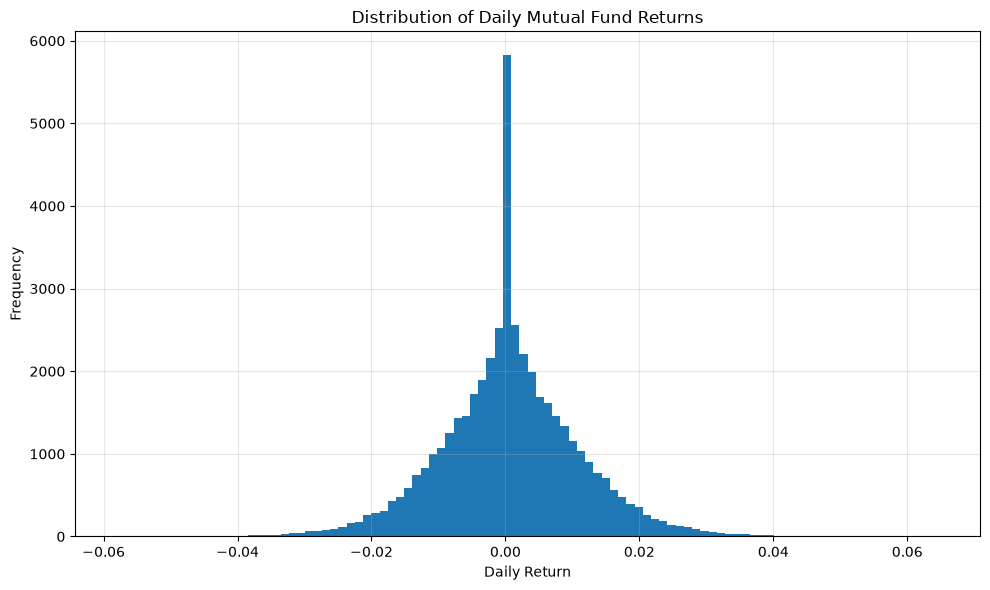

In [4]:
# Validate daily return distribution

daily_returns = nav["daily_return"].dropna()

print("=" * 60)
print("DAILY RETURN VALIDATION")
print("=" * 60)

print("Total daily return observations:", len(daily_returns))
print("Minimum daily return:", daily_returns.min())
print("Maximum daily return:", daily_returns.max())
print("Mean daily return:", daily_returns.mean())
print("Median daily return:", daily_returns.median())
print("Standard deviation:", daily_returns.std())

# Plot distribution
plt.figure(figsize=(10, 6))

plt.hist(
    daily_returns,
    bins=100
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "reports/charts/daily_return_distribution.png",
    dpi=300
)

plt.show()

In [5]:
# TASK 2: CAGR FOR 1 YEAR, 3 YEARS AND 5 YEARS

def calculate_cagr(group, years):
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_target = end_date - pd.DateOffset(years=years)

    start_data = group[group["date"] >= start_target]

    if start_data.empty:
        return np.nan

    start_nav = start_data.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    actual_years = (
        group.iloc[-1]["date"] - start_data.iloc[0]["date"]
    ).days / 365.25

    if actual_years <= 0 or start_nav <= 0:
        return np.nan

    cagr = (
        (end_nav / start_nav) ** (1 / actual_years)
    ) - 1

    return cagr * 100


cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": amfi_code,
        "CAGR_1Y_pct": calculate_cagr(group, 1),
        "CAGR_3Y_pct": calculate_cagr(group, 3),
        "CAGR_5Y_pct": calculate_cagr(group, 5)
    })


cagr_df = pd.DataFrame(cagr_results)

# Add fund names
cagr_df = cagr_df.merge(
    scheme[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "CAGR_1Y_pct",
        "CAGR_3Y_pct",
        "CAGR_5Y_pct"
    ]
]

print("=" * 70)
print("CAGR COMPARISON — ALL 40 FUNDS")
print("=" * 70)

print(cagr_df.to_string(index=False))

print("\nNumber of funds:", len(cagr_df))

CAGR COMPARISON — ALL 40 FUNDS
 amfi_code                                           scheme_name               fund_house  CAGR_1Y_pct  CAGR_3Y_pct  CAGR_5Y_pct
    100016             HDFC Top 100 Fund - Regular Plan - Growth         HDFC Mutual Fund    -2.225777     1.292353     2.637074
    100025          HDFC Short Term Debt Fund - Regular - Growth         HDFC Mutual Fund     3.707553     3.915479     4.458210
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund    53.277195    32.433971    30.123153
    101206         ABSL Frontline Equity Fund - Regular - Growth Aditya Birla Sun Life MF    47.963794    28.960211    23.538361
    101207                ABSL Small Cap Fund - Regular - Growth Aditya Birla Sun Life MF   -24.000309    -4.151454     7.938765
    101208                   ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF     7.241777     6.314299     6.509027
    102885            UTI Nifty 50 Index Fund - Regular - Growth  

In [6]:
# TASK 3: SHARPE RATIO

RISK_FREE_ANNUAL = 0.065

# Convert annual risk-free rate to daily rate
daily_rf = (1 + RISK_FREE_ANNUAL) ** (1 / 252) - 1

sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        excess_return = returns.mean() - daily_rf
        daily_std = returns.std()

        if daily_std > 0:
            sharpe = (
                excess_return / daily_std
            ) * np.sqrt(252)
        else:
            sharpe = np.nan

    else:
        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe
    })


sharpe_df = pd.DataFrame(sharpe_results)

# Add fund names
sharpe_df = sharpe_df.merge(
    scheme[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

# Rank funds
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["sharpe_rank"] = (
    sharpe_df.index + 1
)

print("=" * 70)
print("SHARPE RATIO — ALL 40 FUNDS")
print("=" * 70)

print(
    sharpe_df[
        [
            "sharpe_rank",
            "amfi_code",
            "scheme_name",
            "sharpe_ratio"
        ]
    ].to_string(index=False)
)

print("\nTop 5 Funds by Sharpe Ratio:")
print(
    sharpe_df[
        [
            "scheme_name",
            "sharpe_ratio"
        ]
    ].head(5).to_string(index=False)
)

SHARPE RATIO — ALL 40 FUNDS
 sharpe_rank  amfi_code                                           scheme_name  sharpe_ratio
           1     148567         Mirae Asset Large Cap Fund - Regular - Growth      1.462504
           2     120843                Kotak Flexicap Fund - Regular - Growth      1.319442
           3     148569         Mirae Asset Tax Saver Fund - Regular - Growth      1.246344
           4     119551             SBI Bluechip Fund - Regular Plan - Growth      1.222947
           5     120505              ICICI Pru Midcap Fund - Regular - Growth      1.190559
           6     149323                    DSP Midcap Fund - Regular - Growth      1.143490
           7     100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth      1.104352
           8     118632        Nippon India Large Cap Fund - Regular - Growth      1.095918
           9     101206         ABSL Frontline Equity Fund - Regular - Growth      1.041061
          10     120504             ICICI Pru Bluech

In [7]:
# TASK 4: SORTINO RATIO

sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # Only negative return days
    downside_returns = returns[returns < 0]

    if len(returns) > 1 and len(downside_returns) > 1:

        excess_return = returns.mean() - daily_rf

        downside_std = downside_returns.std()

        if downside_std > 0:
            sortino = (
                excess_return / downside_std
            ) * np.sqrt(252)
        else:
            sortino = np.nan

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino
    })


sortino_df = pd.DataFrame(sortino_results)

# Add fund names
sortino_df = sortino_df.merge(
    scheme[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

# Rank funds
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["sortino_rank"] = (
    sortino_df.index + 1
)

print("=" * 70)
print("SORTINO RATIO — ALL 40 FUNDS")
print("=" * 70)

print(
    sortino_df[
        [
            "sortino_rank",
            "amfi_code",
            "scheme_name",
            "sortino_ratio"
        ]
    ].to_string(index=False)
)

print("\nTop 5 Funds by Sortino Ratio:")

print(
    sortino_df[
        [
            "scheme_name",
            "sortino_ratio"
        ]
    ].head(5).to_string(index=False)
)

SORTINO RATIO — ALL 40 FUNDS
 sortino_rank  amfi_code                                           scheme_name  sortino_ratio
            1     148567         Mirae Asset Large Cap Fund - Regular - Growth       2.409056
            2     120843                Kotak Flexicap Fund - Regular - Growth       2.387295
            3     148569         Mirae Asset Tax Saver Fund - Regular - Growth       2.166757
            4     119551             SBI Bluechip Fund - Regular Plan - Growth       2.166272
            5     120505              ICICI Pru Midcap Fund - Regular - Growth       2.047336
            6     120507              ICICI Pru Liquid Fund - Regular - Growth       1.918995
            7     149323                    DSP Midcap Fund - Regular - Growth       1.893929
            8     118632        Nippon India Large Cap Fund - Regular - Growth       1.874521
            9     100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth       1.846950
           10     120504       

In [8]:
# TASK 5: ALPHA AND BETA USING NIFTY 100

# Prepare NIFTY 100 data
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Calculate NIFTY 100 daily returns
nifty100["nifty100_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100_returns = nifty100[
    ["date", "nifty100_return"]
].dropna()

alpha_beta_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    # Fund daily returns
    fund_returns = group[
        ["date", "daily_return"]
    ].dropna()

    # Match fund returns with NIFTY 100 returns
    merged = fund_returns.merge(
        nifty100_returns,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) >= 30:

        regression = linregress(
            merged["nifty100_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        # Annualized alpha
        alpha = regression.intercept * 252

    else:
        alpha = np.nan
        beta = np.nan

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta
    })


alpha_beta_df = pd.DataFrame(alpha_beta_results)

# Add fund names
alpha_beta_df = alpha_beta_df.merge(
    scheme[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

# Rank by Alpha
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).reset_index(drop=True)

alpha_beta_df["alpha_rank"] = (
    alpha_beta_df.index + 1
)

print("=" * 70)
print("ALPHA & BETA — ALL 40 FUNDS")
print("=" * 70)

print(
    alpha_beta_df[
        [
            "alpha_rank",
            "amfi_code",
            "scheme_name",
            "alpha",
            "beta"
        ]
    ].to_string(index=False)
)

print("\nTop 5 Funds by Alpha:")

print(
    alpha_beta_df[
        [
            "scheme_name",
            "alpha",
            "beta"
        ]
    ].head(5).to_string(index=False)
)

ALPHA & BETA — ALL 40 FUNDS
 alpha_rank  amfi_code                                           scheme_name    alpha      beta
          1     119598            SBI Small Cap Fund - Regular Plan - Growth 0.303370 -0.023196
          2     149324                 DSP Small Cap Fund - Regular - Growth 0.300579  0.011455
          3     120505              ICICI Pru Midcap Fund - Regular - Growth 0.292636  0.000549
          4     148569         Mirae Asset Tax Saver Fund - Regular - Growth 0.282704  0.018134
          5     120843                Kotak Flexicap Fund - Regular - Growth 0.273305 -0.022830
          6     100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.271954  0.005104
          7     148567         Mirae Asset Large Cap Fund - Regular - Growth 0.269838  0.023684
          8     149323                    DSP Midcap Fund - Regular - Growth 0.265986 -0.002523
          9     119094                   Axis Midcap Fund - Regular - Growth 0.260767 -0.066265
         10 

In [9]:
# TASK 6: MAXIMUM DRAWDOWN

drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Worst drawdown
    worst_idx = group["drawdown"].idxmin()

    max_drawdown = group.loc[
        worst_idx, "drawdown"
    ]

    drawdown_end = group.loc[
        worst_idx, "date"
    ]

    # Find the NAV peak before the worst drawdown
    before_drawdown = group[
        group["date"] <= drawdown_end
    ]

    peak_idx = before_drawdown["nav"].idxmax()

    drawdown_start = group.loc[
        peak_idx, "date"
    ]

    peak_nav = group.loc[
        peak_idx, "nav"
    ]

    bottom_nav = group.loc[
        worst_idx, "nav"
    ]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": max_drawdown * 100,
        "drawdown_start": drawdown_start,
        "drawdown_end": drawdown_end,
        "peak_nav": peak_nav,
        "bottom_nav": bottom_nav
    })


drawdown_df = pd.DataFrame(drawdown_results)

# Add fund names
drawdown_df = drawdown_df.merge(
    scheme[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

# Worst drawdowns first
drawdown_df = drawdown_df.sort_values(
    "max_drawdown_pct"
).reset_index(drop=True)

print("=" * 70)
print("MAXIMUM DRAWDOWN — ALL 40 FUNDS")
print("=" * 70)

print(
    drawdown_df[
        [
            "amfi_code",
            "scheme_name",
            "max_drawdown_pct",
            "drawdown_start",
            "drawdown_end"
        ]
    ].to_string(index=False)
)

print("\nWorst 5 Drawdowns:")

print(
    drawdown_df[
        [
            "scheme_name",
            "max_drawdown_pct",
            "drawdown_start",
            "drawdown_end"
        ]
    ].head(5).to_string(index=False)
)

MAXIMUM DRAWDOWN — ALL 40 FUNDS
 amfi_code                                           scheme_name  max_drawdown_pct drawdown_start drawdown_end
    119599             SBI Small Cap Fund - Direct Plan - Growth        -52.574221     2023-01-17   2025-10-28
    119095                Axis Small Cap Fund - Regular - Growth        -51.677754     2025-05-22   2026-05-11
    101207                ABSL Small Cap Fund - Regular - Growth        -35.446916     2024-11-21   2026-05-11
    149324                 DSP Small Cap Fund - Regular - Growth        -31.171900     2024-05-03   2025-01-03
    119598            SBI Small Cap Fund - Regular Plan - Growth        -28.706006     2024-08-28   2025-05-14
    102886                   UTI Mid Cap Fund - Regular - Growth        -28.001124     2025-01-07   2026-04-27
    100016             HDFC Top 100 Fund - Regular Plan - Growth        -24.734441     2022-03-30   2022-09-15
    120842         Kotak Emerging Equity Fund - Regular - Growth        -24.0035

In [10]:
# TASK 7: FUND SCORECARD (0-100)

# Start with the required fund information
scorecard = scheme[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

# Add Sharpe Ratio
scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code",
    how="left"
)

# Add Alpha and Beta
scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha", "beta"]
    ],
    on="amfi_code",
    how="left"
)

# Add Maximum Drawdown
scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code", "max_drawdown_pct"]
    ],
    on="amfi_code",
    how="left"
)

# -------------------------------------------------------
# RANKING
# -------------------------------------------------------

# Higher 3-year return = better
scorecard["return_score"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True) * 100
)

# Higher Sharpe = better
scorecard["sharpe_score"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True) * 100
)

# Higher Alpha = better
scorecard["alpha_score"] = (
    scorecard["alpha"]
    .rank(pct=True) * 100
)

# Lower Expense Ratio = better
scorecard["expense_score"] = (
    100
    - scorecard["expense_ratio_pct"]
    .rank(pct=True) * 100
)

# Less negative Maximum Drawdown = better
# Example: -10% is better than -30%
scorecard["drawdown_score"] = (
    scorecard["max_drawdown_pct"]
    .rank(pct=True) * 100
)

# -------------------------------------------------------
# WEIGHTED FUND SCORE
# -------------------------------------------------------

scorecard["fund_score"] = (
    0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

# Round scores
scorecard["fund_score"] = scorecard["fund_score"].round(2)

# Rank funds from highest score to lowest
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard["overall_rank"] = (
    scorecard.index + 1
)

# -------------------------------------------------------
# DISPLAY
# -------------------------------------------------------

print("=" * 80)
print("FUND SCORECARD — ALL 40 FUNDS")
print("=" * 80)

print(
    scorecard[
        [
            "overall_rank",
            "scheme_name",
            "return_3yr_pct",
            "sharpe_ratio",
            "alpha",
            "expense_ratio_pct",
            "max_drawdown_pct",
            "fund_score"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 80)
print("TOP 5 FUNDS")
print("=" * 80)

print(
    scorecard[
        [
            "overall_rank",
            "scheme_name",
            "fund_score"
        ]
    ].head(5).to_string(index=False)
)

FUND SCORECARD — ALL 40 FUNDS
 overall_rank                                           scheme_name  return_3yr_pct  sharpe_ratio    alpha  expense_ratio_pct  max_drawdown_pct  fund_score
            1              ICICI Pru Midcap Fund - Regular - Growth           18.08      1.190559 0.292636               1.36        -18.188514       79.62
            2                Kotak Flexicap Fund - Regular - Growth           15.65      1.319442 0.273305               1.45        -12.973968       78.62
            3    HDFC Mid-Cap Opportunities Fund - Regular - Growth           16.58      1.104352 0.271954               1.38        -16.217209       75.88
            4            SBI Small Cap Fund - Regular Plan - Growth           23.39      0.953332 0.303370               1.43        -28.706006       75.25
            5         Mirae Asset Large Cap Fund - Regular - Growth           14.81      1.462504 0.269838               1.46        -11.265729       74.62
            6                 DSP 

In [11]:
# Save final fund scorecard

scorecard[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "fund_house",
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "beta",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "fund_score"
    ]
].to_csv(
    "fund_scorecard.csv",
    index=False
)

print("✅ fund_scorecard.csv saved successfully!")
print("Total funds:", len(scorecard))

✅ fund_scorecard.csv saved successfully!
Total funds: 40


In [12]:
# TASK 8: BENCHMARK COMPARISON — TOP 5 FUNDS

# Get Top 5 funds from scorecard
top5_codes = scorecard.head(5)["amfi_code"].tolist()

latest_date = nav["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

print("Analysis period:")
print(start_date.date(), "to", latest_date.date())

# -------------------------------------------------------
# TOP 5 FUND NAV DATA
# -------------------------------------------------------

top5_nav = nav[
    (nav["amfi_code"].isin(top5_codes)) &
    (nav["date"] >= start_date)
].copy()

# -------------------------------------------------------
# NIFTY 50
# -------------------------------------------------------

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50[
    nifty50["date"] >= start_date
].sort_values("date")

nifty50["daily_return"] = (
    nifty50["close_value"].pct_change()
)

# -------------------------------------------------------
# NIFTY 100
# -------------------------------------------------------

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100[
    nifty100["date"] >= start_date
].sort_values("date")

nifty100["daily_return"] = (
    nifty100["close_value"].pct_change()
)

print("\nTop 5 Fund Codes:")
print(top5_codes)

print("\nNIFTY50 observations:", len(nifty50))
print("NIFTY100 observations:", len(nifty100))

Analysis period:
2023-05-29 to 2026-05-29

Top 5 Fund Codes:
[120505, 120843, 100033, 119598, 148567]

NIFTY50 observations: 785
NIFTY100 observations: 785


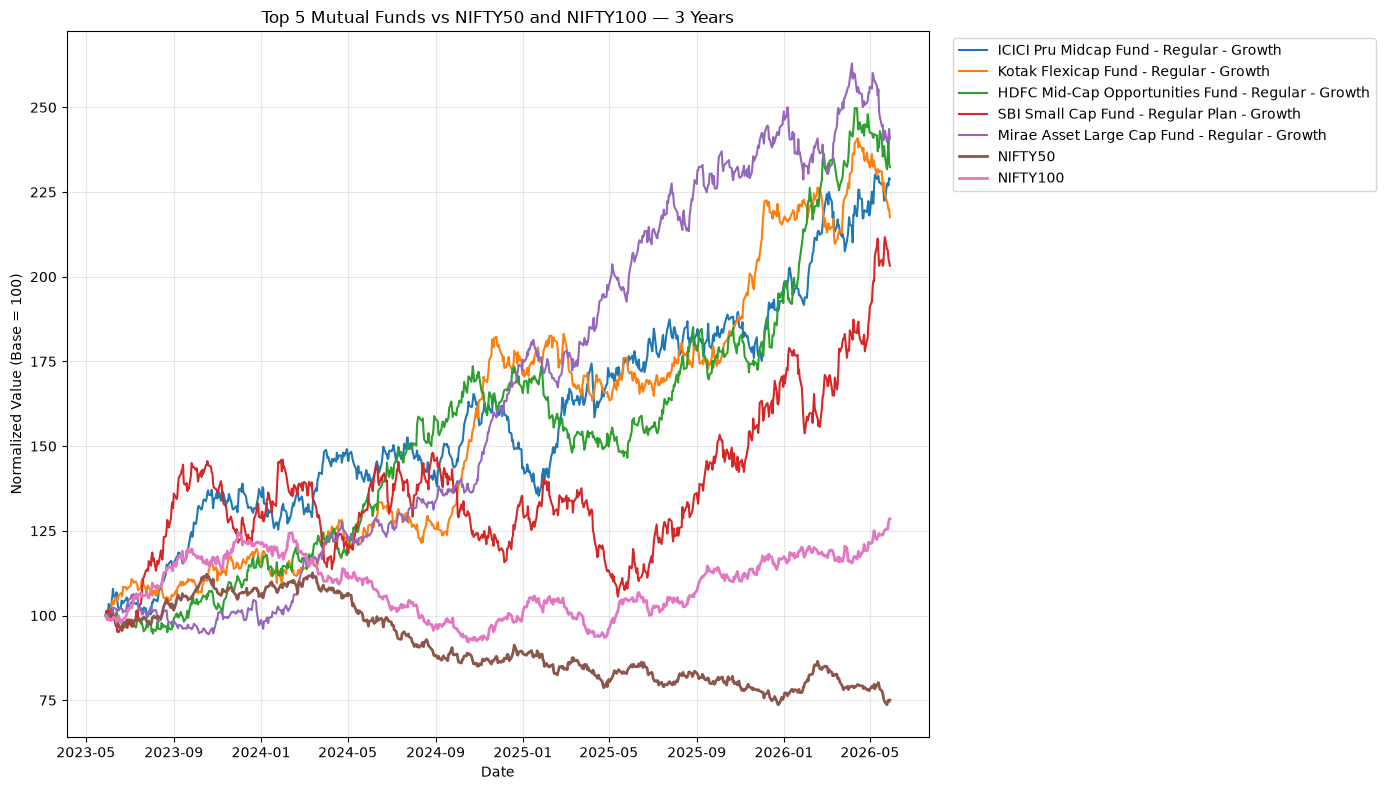

✅ Benchmark comparison chart saved!


In [13]:
# Create normalized benchmark comparison chart

plt.figure(figsize=(14, 8))

# Top 5 funds
for amfi_code in top5_codes:

    fund = top5_nav[
        top5_nav["amfi_code"] == amfi_code
    ].sort_values("date")

    if len(fund) == 0:
        continue

    scheme_name = scorecard.loc[
        scorecard["amfi_code"] == amfi_code,
        "scheme_name"
    ].iloc[0]

    normalized_nav = (
        fund["nav"] / fund["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund["date"],
        normalized_nav,
        label=scheme_name
    )


# NIFTY50
nifty50_normalized = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50_normalized,
    label="NIFTY50",
    linewidth=2
)


# NIFTY100
nifty100_normalized = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100_normalized,
    label="NIFTY100",
    linewidth=2
)


plt.title(
    "Top 5 Mutual Funds vs NIFTY50 and NIFTY100 — 3 Years"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Benchmark comparison chart saved!")

In [14]:
# Calculate Tracking Error against NIFTY100

tracking_results = []

benchmark_returns = nifty100[
    ["date", "daily_return"]
].dropna()

for amfi_code in top5_codes:

    fund = top5_nav[
        top5_nav["amfi_code"] == amfi_code
    ][
        ["date", "daily_return"]
    ].dropna()

    merged = fund.merge(
        benchmark_returns,
        on="date",
        suffixes=("_fund", "_benchmark")
    )

    if len(merged) > 1:

        active_returns = (
            merged["daily_return_fund"]
            - merged["daily_return_benchmark"]
        )

        tracking_error = (
            active_returns.std()
            * np.sqrt(252)
        )

    else:
        tracking_error = np.nan

    scheme_name = scorecard.loc[
        scorecard["amfi_code"] == amfi_code,
        "scheme_name"
    ].iloc[0]

    tracking_results.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name,
        "tracking_error": tracking_error
    })


tracking_error_df = pd.DataFrame(
    tracking_results
)

print("=" * 70)
print("TRACKING ERROR — TOP 5 FUNDS vs NIFTY100")
print("=" * 70)

print(
    tracking_error_df.to_string(index=False)
)

TRACKING ERROR — TOP 5 FUNDS vs NIFTY100
 amfi_code                                        scheme_name  tracking_error
    120505           ICICI Pru Midcap Fund - Regular - Growth        0.232661
    120843             Kotak Flexicap Fund - Regular - Growth        0.206540
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.224976
    119598         SBI Small Cap Fund - Regular Plan - Growth        0.286689
    148567      Mirae Asset Large Cap Fund - Regular - Growth        0.187974


In [15]:
# Save Alpha and Beta results

alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "alpha",
        "beta"
    ]
].to_csv(
    "alpha_beta.csv",
    index=False
)

print("✅ alpha_beta.csv saved successfully!")

✅ alpha_beta.csv saved successfully!
